# 15_05 — Modelos de referencia · Escenario 5 · predictibilidad en componente subordinada

Paso **3c**, posterior a `15_04_evaluacion`. Eje 1 de `§03_06`: el PSBPM-FD
contra los modelos de referencia, sobre la misma representación y con el mismo
conjunto de información. Sólo métricas **puntuales**.

| Modelo | Qué es | Referencia |
|---|---|---|
| `VAR` | VAR($p$) sobre los scores, con intercepto | Aue, Norinho & Hörmann (2015) |
| `FAR1` | $\hat\Psi=\hat C_1\hat C_0^{-1}$ en el subespacio FPCA | Bosq (2000) |
| `RF` | bosque aleatorio multisalida | no lineal |
| `GBT` | *gradient boosting* por score | no lineal |
| `media`, `persistencia` | líneas base de `fit/baselines.py` | piso |

Bloque 2: la dinámica es lineal, gaussiana y **escalar por componente**, con
$\phi=0.9$ en una sola dirección de Fourier. `VAR` es el techo práctico. La
cifra informativa no es el promedio de RMSE sino la tabla **por componente**:
la señal vive en una sola dirección y el promedio la diluye.

Con $M=4$ el truncamiento retiene esa dirección, de modo que el escenario está
en **caso nulo** y no responde `§03_06`, que exige $M\le 2$. La §6.1 lo
reevalúa sobre los artefactos.

## 1. Imports, rutas y artefactos

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.fit import (
    rmse_por_coeficiente, r2_por_columna, razon_dispersion,
    mise, rmse_funcional, ventana_movil_funcional,
)
from model_psbp_fd.graphics import plot_ventana_movil
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [3]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] debe coincidir con 15_01, 15_03, 15_04 y psbp_fd_iteracion.m
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario", 5, 1
EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID,
    "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID,
}
for r in PATHS.values():
    r.mkdir(parents=True, exist_ok=True)

# Este notebook NO pisa nada de 15_04: los _04 ocupan 50-65 segun el
# escenario, y este escribe 70-75.
PREFIJO = 70
print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")
print(f"salidas       : {PATHS['out_report']}  (archivos 70-75)")

EXPERIMENT_ID : escenario_5_r01
salidas       : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_5_r01  (archivos 70-75)


In [4]:
dfs_train, manifest = cargar_datasets_ar(PATHS, bloque="train")
dfs_test,  _        = cargar_datasets_ar(PATHS, bloque="test")
hp_json     = cargar_hiperparametros(PATHS)
eval_config = cargar_config_evaluacion(PATHS)

COMPONENT_IDX = manifest["component_idx"]
n_components  = len(COMPONENT_IDX)
cov_names     = list(manifest["cov_names"])
N_LAGS        = int(manifest["n_lags"])
T, T0         = int(manifest["T"]), int(manifest["T0"])

assert manifest["scores_scale"] == "standardized_zscore_ddof0"

MODO_RESIDUO = eval_config.get("modo_residuo", "ninguno")
OBJETIVO     = eval_config.get("objetivo_evaluacion", "curva_verdadera")
VENTANAS_W   = list(eval_config.get("ventana_movil", {}).get("w", [10, 20, 40]))

assert OBJETIVO == "curva_verdadera", (
    f"objetivo_evaluacion={OBJETIVO!r}. Este notebook compara contra la curva "
    "verdadera; con otro objetivo las cifras no serian las del _04.")

print(f"T={T}  T0={T0}  n_lags={N_LAGS}  componentes={n_components}")
print(f"objetivo={OBJETIVO!r}  ·  modo_residuo={MODO_RESIDUO!r}")
print(f"covariables ({len(cov_names)}): {cov_names}")

T=400  T0=280  n_lags=1  componentes=5
objetivo='curva_verdadera'  ·  modo_residuo='ninguno'
covariables (5): ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1']


In [5]:
fpca = cargar_fpca(PATHS)
_ver = fpca.verificar()
assert _ver["todo_ok"], f"Las identidades FPCA no se cumplen: {_ver}"

scores_standardizer = cargar_estandarizador(PATHS, DataStandardizer)
X_obs, grilla = cargar_curvas(PATHS)        # (T, G) con ruido de medicion
X_true        = cargar_curvas_true(PATHS)   # (T, G) verdadera — el objetivo

M_fpca     = fpca.M
SCORES     = fpca.SCORES                     # (T, M) escala original, centrados
SCORES_STD = scores_standardizer.transform(SCORES)

assert COMPONENT_IDX == list(range(M_fpca)), (
    "La reconstruccion funcional necesita el vector completo de scores en "
    f"orden; COMPONENT_IDX={COMPONENT_IDX} y M={M_fpca}.")
assert scores_standardizer.n_ajuste == T0, (
    f"El estandarizador se ajusto con n={scores_standardizer.n_ajuste} y T0={T0}: "
    "habria fuga del bloque de prueba.")

print(f"FPCA M={M_fpca} K={fpca.K}  ·  curvas {X_true.shape}  grilla {grilla.shape}")
print(f"varianza explicada por las M retenidas: {fpca.meta['var_explained']:.4%}")

FPCA M=5 K=12  ·  curvas (400, 75)  grilla (75,)
varianza explicada por las M retenidas: 96.7192%


## 2. Serie de orígenes y matriz de diseño

In [6]:
dfs_full = {k: pd.concat([dfs_train[k], dfs_test[k]], ignore_index=True)
            for k in range(n_components)}
n_orig  = len(dfs_full[0])
t_orig  = np.arange(N_LAGS + 1, T + 1)      # tiempo del experimento, base-1
assert len(t_orig) == n_orig, f"{len(t_orig)} != {n_orig}"

T0_orig  = T0 - N_LAGS                       # corte en el indexado de origenes
es_train = t_orig <= T0

# Objetivo (n_orig, M) en escala estandarizada, y matriz de diseno comun.
Y_obs = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy(dtype=float)
                         for k in range(n_components)])

_cols0 = list(dfs_full[0].columns[1:])
for k in range(1, n_components):
    assert list(dfs_full[k].columns[1:]) == _cols0, (
        f"La componente k={k} usa covariables distintas de la k=0; la matriz "
        "de diseno comun deja de ser valida.")
assert _cols0 == cov_names, (
    f"Las columnas del dataset {_cols0} no son cov_names {cov_names}.")

Z = np.asarray(dfs_full[0].iloc[:, 1:], dtype=float)     # (n_orig, p)
p_dis = Z.shape[1]

print(f"origenes evaluados : {n_orig}  (train {es_train.sum()} · test {(~es_train).sum()})")
print(f"matriz de diseno Z : {Z.shape}   objetivo Y : {Y_obs.shape}")
print(f"corte T0={T0}  ->  indice de origen T0_orig={T0_orig}")

origenes evaluados : 399  (train 279 · test 120)
matriz de diseno Z : (399, 5)   objetivo Y : (399, 5)
corte T0=280  ->  indice de origen T0_orig=279


In [7]:
# Curvas de referencia alineadas a los origenes, y el piso de la representacion.
X_true_ev = X_true[N_LAGS:]                       # (n_orig, G) VERDADERA
X_proj    = fpca.reconstruct(SCORES)[N_LAGS:]     # proyeccion FPCA sin modelo


def curvas_desde_scores_std(Y_std_pred):
    """Prediccion en scores estandarizados -> curvas en la grilla (n, G).

    Es el mapa determinista de `PropagadorFuncional` con modo_residuo="ninguno":
    des-estandarizar y reconstruir. Se escribe aqui y no se instancia el
    propagador porque este devuelve extracciones de una predictiva y aqui solo
    hay una media condicional.
    """
    S = scores_standardizer.inverse_transform(np.atleast_2d(Y_std_pred))
    return fpca.reconstruct(S)


# Control: reconstruir el objetivo observado debe dar exactamente X_proj.
assert np.allclose(curvas_desde_scores_std(Y_obs), X_proj, atol=1e-8), (
    "El mapa scores->curva no reproduce la proyeccion FPCA; revisar el "
    "estandarizador cargado.")

MISE_TRUNC = {b: mise(X_true_ev[m], X_proj[m], grilla)
              for b, m in (("train", es_train), ("test", ~es_train))}
print("MISE del TRUNCAMIENTO FPCA (piso comun a todos los modelos):")
for b, v in MISE_TRUNC.items():
    print(f"  {b:5s}: {v:.6f}")
print("  <- ningun modelo sobre esta representacion puede bajar de ahi")

MISE del TRUNCAMIENTO FPCA (piso comun a todos los modelos):
  train: 0.065339
  test : 0.057132
  <- ningun modelo sobre esta representacion puede bajar de ahi


## 3. Los competidores

Cada uno se ajusta **sólo con los orígenes de entrenamiento** y devuelve
`(n_orig, M)` predicciones a $h=1$ en escala estandarizada.

### 3.1 VAR($p$) sobre los scores — Aue, Norinho & Hörmann (2015)

Con $p=N_{lags}$ el regresor es la matriz de diseño del PSBPM-FD, de modo que
el VAR es el caso lineal-gaussiano **anidado** en el modelo propuesto.

In [8]:
def ajustar_var(Z, Y, mask_train):
    """VAR(p) por MCO con intercepto, estimado solo en `mask_train`.

    Se resuelve con `lstsq` y no con la ecuacion normal: con M y p pequenos el
    condicionamiento no es problema, pero la forma normal eleva al cuadrado el
    numero de condicion sin ninguna ganancia.
    """
    Zc = np.hstack([np.ones((Z.shape[0], 1)), Z])
    coef, *_ = np.linalg.lstsq(Zc[mask_train], Y[mask_train], rcond=None)
    return Zc @ coef, coef


PRED = {}          # {nombre: (n_orig, M) en escala estandarizada}
INFO = {}          # notas por modelo, para el resumen

PRED["VAR"], coef_var = ajustar_var(Z, Y_obs, es_train)
INFO["VAR"] = f"p={N_LAGS}, {coef_var.size} parametros"
print(f"VAR({N_LAGS}) ajustado con {int(es_train.sum())} origenes · "
      f"{coef_var.shape[0]} coef. x {coef_var.shape[1]} ecuaciones")

VAR(1) ajustado con 279 origenes · 6 coef. x 5 ecuaciones


In [9]:
# [DIAGNOSTICO] orden que el BIC elegiria con libertad, sobre la serie de
# scores completa. No se usa para predecir: solo dice si N_LAGS deja fuera
# dependencia que el VAR podria aprovechar.
def bic_var(SCORES_STD, T0, p):
    S = np.asarray(SCORES_STD, dtype=float)
    T_, M_ = S.shape
    Yp = S[p:]
    Zp = np.hstack([S[p - j - 1:T_ - j - 1] for j in range(p)])
    Zp = np.hstack([np.ones((Zp.shape[0], 1)), Zp])
    tr = np.arange(p, T_) < T0
    coef, *_ = np.linalg.lstsq(Zp[tr], Yp[tr], rcond=None)
    E = Yp[tr] - Zp[tr] @ coef
    n_ = E.shape[0]
    Sig = E.T @ E / n_
    signo, logdet = np.linalg.slogdet(Sig)
    return n_ * logdet + np.log(n_) * coef.size


P_MAX = 5
_bics = {p: bic_var(SCORES_STD, T0, p) for p in range(1, P_MAX + 1)}
_p_bic = min(_bics, key=_bics.get)
print(f"{'p':>3}  {'BIC':>12}")
for p, v in _bics.items():
    print(f"{p:>3}  {v:>12.2f}" + ("   <- minimo" if p == _p_bic else ""))
print(f"\nBIC elige p={_p_bic}; el estudio fija N_LAGS={N_LAGS}."
      + ("  OK coinciden" if _p_bic == N_LAGS else
         "  <- declarar esta restriccion al reportar"))

  p           BIC
  1       -239.95   <- minimo
  2       -118.57
  3          2.16
  4        109.28
  5        225.59

BIC elige p=1; el estudio fija N_LAGS=1.  OK coinciden


### 3.2 FAR(1) sobre la curva — Bosq (2000)

Opera sobre los scores en escala original y **sin intercepto**. En coordenadas
FPCA —ortonormales en $L^2$— la norma de Hilbert-Schmidt del operador es la
norma de Frobenius de una matriz M×M.

In [10]:
RIDGE_FAR = 0.0   # [CONFIG] regularizacion de C0. Con M pequeno no hace falta.

# [CONFIG] estructura declarada del generador de este escenario, contra la que
# se contrasta la norma estimada. Es lo unico de esta seccion que cambia entre
# escenarios.
HS_REFERENCIA = "phi = 0.9 en una sola dirección de Fourier, 0 en el resto"


def ajustar_far1(SCORES, T0, N_LAGS, ridge=0.0):
    """FAR(1) por Yule-Walker en el subespacio FPCA.

    Devuelve (Xi_pred, Psi_hat) con Xi_pred alineado a los origenes
    t = N_LAGS+1 .. T, en escala ORIGINAL de scores.
    """
    S = np.asarray(SCORES, dtype=float)
    T_ = S.shape[0]
    Xi_lag = S[N_LAGS - 1:T_ - 1]        # valor en t-1 de cada origen
    Xi_now = S[N_LAGS:]                  # valor en t
    tr = np.arange(N_LAGS + 1, T_ + 1) <= T0

    A, Bm = Xi_lag[tr], Xi_now[tr]
    n_ = A.shape[0]
    C0 = A.T @ A / n_
    C1 = Bm.T @ A / n_
    if ridge > 0:
        C0 = C0 + ridge * np.trace(C0) / C0.shape[0] * np.eye(C0.shape[0])
    Psi_hat = np.linalg.solve(C0.T, C1.T).T      # C1 @ inv(C0), sin invertir
    return Xi_lag @ Psi_hat.T, Psi_hat


# Los parametros REALES del generador se leen del artefacto que escribio el
# _01, no de una constante copiada a mano: el notebook _01 es la fuente de
# verdad y puede cambiar sin que nadie actualice este texto.
import json as _json

_p_sim = PATHS["raw"] / "simulation_config.json"
SIM_PARAMS = {}
if _p_sim.exists():
    SIM_PARAMS = _json.loads(_p_sim.read_text(encoding="utf-8")).get("sim_params", {})


Xi_far, Psi_hat = ajustar_far1(SCORES, T0, N_LAGS, ridge=RIDGE_FAR)
PRED["FAR1"] = scores_standardizer.transform(Xi_far)

_hs   = float(np.linalg.norm(Psi_hat, "fro"))
_rho  = float(np.max(np.abs(np.linalg.eigvals(Psi_hat))))
_cond = float(np.linalg.cond(np.cov(SCORES[N_LAGS - 1:T0 - 1].T)))
INFO["FAR1"] = f"K={M_fpca}, ||Psi||_HS={_hs:.4f}"

print(f"||Psi_hat||_HS   = {_hs:.4f}")
print(f"generador        : {HS_REFERENCIA}")
# La condicion de estacionariedad es sobre el RADIO ESPECTRAL; ||Psi||_HS < 1
# la implica pero no al reves, y en escenarios con salto de nivel la norma HS
# se dispara sin que el operador deje de ser contractivo.
print(f"radio espectral  = {_rho:.4f}   "
      + ("OK contractivo" if _rho < 1 else "<- NO contractivo"))
print(f"cond(C0)         = {_cond:.1f}")

if SIM_PARAMS:
    _rel = [k for k in SIM_PARAMS
            if any(s in k for s in ("hs_norm", "phi", "gamma", "ell",
                                    "desplaz", "mecanismo", "sigma_eps",
                                    "familia", "delta", "nu", "persistencia",
                                    "razon_espectro", "indice", "J"))]
    print("\nparametros del generador leidos de simulation_config.json:")
    for k in sorted(_rel):
        print(f"   {k:24s} = {SIM_PARAMS[k]}")
else:
    print(f"\nAVISO no se encontro {_p_sim}: los parametros del generador")
    print("no pudieron verificarse contra el artefacto.")

print()
print("""El Algoritmo 5 no tiene un operador funcional: son recursiones ESCALARES e
independientes sobre coeficientes de Fourier, con phi = 0.9 unicamente en la
componente j*=3 y 0 en las demas. La norma de arriba deberia acercarse a 0.9
SI el subespacio FPCA retenido contiene esa direccion, y a 0 si la descarta:
es por si sola el diagnostico del caso nulo.""")

||Psi_hat||_HS   = 0.9082
generador        : phi = 0.9 en una sola dirección de Fourier, 0 en el resto
radio espectral  = 0.8574   OK contractivo
cond(C0)         = 14.6

parametros del generador leidos de simulation_config.json:
   J                        = 10
   indice_predecible        = 3
   phi_predecible           = 0.9
   phis                     = None
   razon_espectro           = 0.5

El Algoritmo 5 no tiene un operador funcional: son recursiones ESCALARES e
independientes sobre coeficientes de Fourier, con phi = 0.9 unicamente en la
componente j*=3 y 0 en las demas. La norma de arriba deberia acercarse a 0.9
SI el subespacio FPCA retenido contiene esa direccion, y a 0 si la descarta:
es por si sola el diagnostico del caso nulo.


### 3.3 Modelos de aprendizaje automático

Sin validación cruzada sobre el bloque de prueba, y con hiperparámetros fijos
entre escenarios. Acotan cuánto de la ventaja del modelo propuesto es **no
linealidad** y cuánto es la **mezcla**.

In [11]:
SEED_ML = 20260830

# [CONFIG] Hiperparametros fijos, sin ajuste por validacion cruzada, e
# IDENTICOS en los seis escenarios.
#   min_samples_leaf alto y max_leaf_nodes moderado porque n_train ~ 280
#   origenes: con arboles profundos el sobreajuste se ve en train y no dice
#   nada sobre el test.
PARAMS_RF  = dict(n_estimators=500, min_samples_leaf=5, max_features="sqrt",
                  random_state=SEED_ML, n_jobs=-1)
PARAMS_GBT = dict(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                  min_samples_leaf=10, early_stopping=False,
                  random_state=SEED_ML)

rf = RandomForestRegressor(**PARAMS_RF).fit(Z[es_train], Y_obs[es_train])
PRED["RF"] = rf.predict(Z)
INFO["RF"] = (f"n_estimators={PARAMS_RF['n_estimators']}, "
              f"leaf>={PARAMS_RF['min_samples_leaf']}")

# HistGradientBoosting es univariante: un modelo por score, misma Z.
pred_gbt = np.empty_like(Y_obs)
for k in range(n_components):
    g = HistGradientBoostingRegressor(**PARAMS_GBT)
    g.fit(Z[es_train], Y_obs[es_train, k])
    pred_gbt[:, k] = g.predict(Z)
PRED["GBT"] = pred_gbt
INFO["GBT"] = (f"max_iter={PARAMS_GBT['max_iter']}, "
               f"lr={PARAMS_GBT['learning_rate']}")

print(f"RF  ajustado: {int(es_train.sum())} origenes x {p_dis} covariables (multisalida)")
print(f"GBT ajustado: {n_components} modelos univariantes sobre la misma Z")

RF  ajustado: 279 origenes x 5 covariables (multisalida)
GBT ajustado: 5 modelos univariantes sobre la misma Z


### 3.4 Las dos líneas base

Sobre la serie completa de orígenes, para que entren en la misma tabla. La
media incondicional es cero en escala estandarizada, y su RMSE cercano a 1 es
la unidad de lectura.

In [12]:
PRED["media"] = np.zeros_like(Y_obs)
INFO["media"] = "cero por construccion en escala estandarizada"

# Persistencia: el score observado en t-1. Para el primer origen (t = N_LAGS+1)
# el valor en t-1 = N_LAGS existe en SCORES_STD, de modo que no hay hueco.
PRED["persistencia"] = SCORES_STD[N_LAGS - 1:T - 1]
INFO["persistencia"] = "y_hat(t) = y(t-1)"

assert all(v.shape == Y_obs.shape for v in PRED.values()), {
    k: v.shape for k, v in PRED.items()}
print("modelos listos:", ", ".join(PRED))

modelos listos: VAR, FAR1, RF, GBT, media, persistencia


## 4. Métricas puntuales, entrenamiento contra prueba

Dos niveles: scores en escala estandarizada, y curva contra la **verdadera**
con `modo_residuo="ninguno"`. El piso de truncamiento va como fila propia.

In [13]:
def metricas_modelo(nombre, Y_pred):
    """Fila por bloque con las metricas puntuales de los dos niveles."""
    filas = []
    X_pred = curvas_desde_scores_std(Y_pred)
    for etq, mask in (("train", es_train), ("test", ~es_train)):
        y, q = Y_obs[mask], Y_pred[mask]
        filas.append({
            "modelo": nombre, "bloque": etq,
            "RMSE_scores": float(rmse_por_coeficiente(y, q).mean()),
            "R2_scores":   float(np.nanmean(r2_por_columna(y, q, centrar=True))),
            "sd_ratio":    float(np.nanmean(razon_dispersion(y, q))),
            "MISE":        mise(X_true_ev[mask], X_pred[mask], grilla),
            "RMSE_func":   rmse_funcional(X_true_ev[mask], X_pred[mask], grilla),
            "n": int(mask.sum()),
        })
    return filas


comp_df = pd.DataFrame([f for nom, Yp in PRED.items()
                        for f in metricas_modelo(nom, Yp)])

# El piso de truncamiento entra como una fila mas: no es un modelo, es la cota.
comp_df = pd.concat([comp_df, pd.DataFrame([
    {"modelo": "(truncamiento FPCA)", "bloque": b, "RMSE_scores": np.nan,
     "R2_scores": np.nan, "sd_ratio": np.nan, "MISE": MISE_TRUNC[b],
     "RMSE_func": rmse_funcional(X_true_ev[m], X_proj[m], grilla),
     "n": int(m.sum())}
    for b, m in (("train", es_train), ("test", ~es_train))])], ignore_index=True)

comp_df = comp_df.set_index(["bloque", "modelo"]).sort_index()
comp_df.to_csv(PATHS["out_report"] / f"{PREFIJO}_comparacion_modelos.csv")

display(comp_df.style
        .format({"RMSE_scores": "{:.4f}", "R2_scores": "{:.4f}",
                 "sd_ratio": "{:.4f}", "MISE": "{:.6f}", "RMSE_func": "{:.6f}"},
                na_rep="—")
        .background_gradient(subset=["RMSE_scores"], cmap="RdYlGn_r")
        .background_gradient(subset=["MISE"], cmap="RdYlGn_r")
        .set_caption("Metricas PUNTUALES por modelo y bloque · MISE contra la "
                     "curva VERDADERA"))

In [14]:
# RMSE por componente: el promedio de la tabla anterior puede esconder que un
# modelo gane en la primera componente y pierda en las demas, que es lo que
# ocurre cuando el espectro FPCA es muy desigual o cuando la senal esta
# concentrada en una sola direccion.
filas_k = []
for nom, Yp in PRED.items():
    for etq, mask in (("train", es_train), ("test", ~es_train)):
        r = rmse_por_coeficiente(Y_obs[mask], Yp[mask])
        filas_k.append({"modelo": nom, "bloque": etq,
                        **{f"FPC{COMPONENT_IDX[k] + 1}": float(r[k])
                           for k in range(n_components)}})
rmse_k_df = pd.DataFrame(filas_k).set_index(["bloque", "modelo"]).sort_index()
rmse_k_df.to_csv(PATHS["out_report"] / f"{PREFIJO + 1}_rmse_por_componente.csv")

display(rmse_k_df.loc["test"].style.format("{:.4f}")
        .background_gradient(cmap="RdYlGn_r", axis=0)
        .set_caption("RMSE por componente FPCA · bloque de PRUEBA"))

,FPC1,FPC2,FPC3,FPC4,FPC5
modelo,,,,,
FAR1,0.9741,0.8837,0.5616,1.0352,0.9870
GBT,1.1376,1.0841,0.6593,1.0969,1.1389
RF,0.9759,0.9025,0.6141,1.0330,1.0259
VAR,0.9738,0.8837,0.5615,1.0354,0.9863
media,0.9682,0.8805,1.0516,1.0581,0.9982
persistencia,1.4074,1.2144,0.5935,1.5501,1.3283


## 5. Ventana móvil del error funcional

Ningún modelo se reentrena: se desliza la ventana de *evaluación*. Una figura
por ancho, con **sólo los modelos**; las ventanas que cruzan $T_0$ van
punteadas.

In [15]:
# ── Prediccion PUNTUAL del PSBPM-FD, recalculada aqui ──────────────────────
# Se leen las trazas y se toma SOLO la media predictiva por score. Es lo unico
# que necesita el MISE de un punto, y evita depender de que el _04 haya
# persistido su tabla de ventana movil para cada ancho: solo guarda la de su w
# de referencia.
from scipy.io import loadmat

from model_psbp_fd.models.pspb_fd_v3 import PSBPPredictor

N_ITER    = int(hp_json["n_iter"])
_MCMC_CFG = hp_json["mcmc_config"]
_CLAVES_TRAZA = ["betajhout", "beta0hout", "tauhout", "alphahout", "psijhout",
                 "Gammajhout", "gammajhout", "pijout", "wjout", "osumout",
                 "inEout"]


def _ruta_traza(fpc_idx, chain):
    return PATHS["out_artefact"] / f"chain_fpc_{fpc_idx}_iter{chain:02d}.mat"


_faltan = [_ruta_traza(COMPONENT_IDX[k] + 1, c + 1).name
           for k in range(n_components) for c in range(N_ITER)
           if not _ruta_traza(COMPONENT_IDX[k] + 1, c + 1).exists()]

X_pred_psbp = None
if _faltan:
    print(f"AVISO faltan {len(_faltan)} trazas .mat: {_faltan[:3]}...")
    print("El PSBPM-FD se tomara del CSV del _04 si existe, y solo para su w.")
else:
    _diseno = np.hstack([np.ones((Z.shape[0], 1)), Z])
    Y_hat_psbp = np.empty_like(Y_obs)
    for k in range(n_components):
        medias = []
        for c in range(N_ITER):
            m = loadmat(str(_ruta_traza(COMPONENT_IDX[k] + 1, c + 1)))
            feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
            assert feat == cov_names, (
                f"[k={k} c={c+1}] feature_names={feat} != cov_names={cov_names}")
            tr = {kk: np.asarray(m[kk], dtype=np.float64) for kk in _CLAVES_TRAZA}
            pr = PSBPPredictor(traces=tr, burn=int(np.asarray(m["burn"]).ravel()[0]))
            medias.append(pr.momentos_predictivos(_diseno)["media"])
        # Media entre cadenas con peso igual: es la media de la mezcla, que es
        # lo que `agrupar_momentos` hace para el primer momento.
        Y_hat_psbp[:, k] = np.column_stack(medias).mean(axis=1)

    X_pred_psbp = curvas_desde_scores_std(Y_hat_psbp)
    print(f"PSBPM-FD recalculado: {n_components} componentes x {N_ITER} cadenas")

    # Verificacion contra el _04. No son identicos y no deben serlo: el _04
    # estima la media promediando S_FUNC extracciones adelgazadas de la
    # predictiva, mientras que esta es la media ANALITICA de la mezcla. La
    # diferencia es error Monte Carlo del _04, de orden 1/sqrt(S_FUNC), y la
    # cifra de aqui es la mas precisa de las dos. Lo que el chequeo descarta es
    # una discrepancia de configuracion, que seria de otro orden de magnitud.
# El tamano del error MC del _04 escala como sd_predictiva / sqrt(S_FUNC), de
# modo que NO es una constante entre escenarios: en el 2 y el 3 la predictiva
# es mucho mas dispersa —heterocedasticidad y saltos de regimen— y la
# discrepancia es varias veces la del 1 sin que nada este mal. Por eso el
# umbral duro solo caza un desajuste de CONFIGURACION, que seria de otro orden.
TOL_AVISO = 0.01     # por encima: vale la pena mirarlo
TOL_DURO  = 0.05     # por encima: no es error Monte Carlo
_f51 = PATHS["out_report"] / "51_metricas_funcionales.csv"
if _f51.exists():
    _m04 = float(pd.read_csv(_f51, index_col=0).loc["test", "MISE"])
    _m05 = mise(X_true_ev[~es_train], X_pred_psbp[~es_train], grilla)
    _dif = abs(_m05 - _m04) / _m04
    print(f"MISE test — _04: {_m04:.6f}   recalculado: {_m05:.6f}   "
          f"dif rel: {_dif:.2e}")
    if _dif < TOL_AVISO:
        print("   compatible con el error Monte Carlo del _04; la cifra")
        print("   recalculada es la mas precisa de las dos.")
    else:
        print(f"   POR ENCIMA de {TOL_AVISO:.0%}. Sigue siendo plausible si la")
        print("   predictiva de este escenario es muy dispersa, pero conviene")
        print("   subir S_FUNC en el _04 antes de citar su MISE como definitivo.")
    assert _dif < TOL_DURO, (
        f"El MISE recalculado difiere del _04 en {_dif:.1%}, demasiado para ser "
        "error Monte Carlo. Revisar si el _04 corrio con otra configuracion "
        "(modo_residuo, objetivo de evaluacion o particion).")

PSBPM-FD recalculado: 5 componentes x 3 cadenas
MISE test — _04: 1.656905   recalculado: 1.640594   dif rel: 9.84e-03
   compatible con el error Monte Carlo del _04; la cifra
   recalculada es la mas precisa de las dos.


In [16]:
# [CONFIG] Que series entran en las FIGURAS. Las tablas y los CSV llevan todo.
#   Fuera van las que NO son modelos: las dos lineas base y la cota de
#   truncamiento. Su unico efecto en la figura es estirar el eje vertical y
#   comprimir las diferencias entre competidores, que es lo que se quiere ver.
#   En el Escenario 6 la cota SI es el resultado central: alli conviene
#   quitarla de este conjunto.
EXCLUIR_DE_FIGURA = {"media", "persistencia", "(truncamiento FPCA)"}

W_COMP = VENTANAS_W[len(VENTANAS_W) // 2]   # ancho de referencia para las tablas
print(f"anchos de ventana: {VENTANAS_W}   ·   referencia para las tablas: w={W_COMP}")


def tabla_ventana(w):
    """Todas las series de este escenario sobre ventanas de ancho w."""
    partes = []
    for nom, Yp in PRED.items():
        t_ = ventana_movil_funcional(X_true_ev, curvas_desde_scores_std(Yp),
                                     grilla, T0_orig, w=w, t_offset=N_LAGS,
                                     verbose=False)
        t_["modelo"] = nom
        partes.append(t_)

    t_tr = ventana_movil_funcional(X_true_ev, X_proj, grilla, T0_orig, w=w,
                                   t_offset=N_LAGS, verbose=False)
    t_tr["modelo"] = "(truncamiento FPCA)"
    partes.append(t_tr)

    # PSBPM-FD: de la prediccion recalculada arriba, que existe para CUALQUIER
    # w. Si las trazas no estaban, se recurre al CSV del _04 —buscado por
    # PATRON, porque su prefijo cambia entre escenarios (57_ en la corrida 11,
    # 58_ en las 12-16)— que solo cubre el w de referencia de aquel notebook.
    if X_pred_psbp is not None:
        t_ps = ventana_movil_funcional(X_true_ev, X_pred_psbp, grilla, T0_orig,
                                       w=w, t_offset=N_LAGS, verbose=False)
        t_ps["modelo"] = "PSBPM-FD"
        partes.append(t_ps)
        origen = "trazas .mat (recalculado)"
    else:
        cand = sorted(PATHS["out_report"].glob(f"*_ventana_funcional_w{w}.csv"))
        if cand:
            t_ps = pd.read_csv(cand[0])
            t_ps["modelo"] = "PSBPM-FD"
            partes.append(t_ps[["t_centro", "bloque", "cruza_T0", "mise", "modelo"]])
            origen = cand[0].name
        else:
            origen = None

    out = pd.concat(partes, ignore_index=True)
    out.attrs["w"] = w
    return out, origen


tablas_w = {}
for w in VENTANAS_W:
    tablas_w[w], _org = tabla_ventana(w)
    tablas_w[w].to_csv(
        PATHS["out_report"] / f"{PREFIJO + 2}_ventana_modelos_w{w}.csv", index=False)
    n_series = tablas_w[w]["modelo"].nunique()
    print(f"  w={w:>3}: {n_series} series · {len(tablas_w[w])} filas"
          + (f" · PSBPM-FD desde {_org}" if _org else " · SIN PSBPM-FD"))

ventana_df = tablas_w[W_COMP]        # la que consumen las tablas numericas

anchos de ventana: [10, 20, 40]   ·   referencia para las tablas: w=20
  w= 10: 8 series · 3120 filas · PSBPM-FD desde trazas .mat (recalculado)
  w= 20: 8 series · 3040 filas · PSBPM-FD desde trazas .mat (recalculado)
  w= 40: 8 series · 2880 filas · PSBPM-FD desde trazas .mat (recalculado)


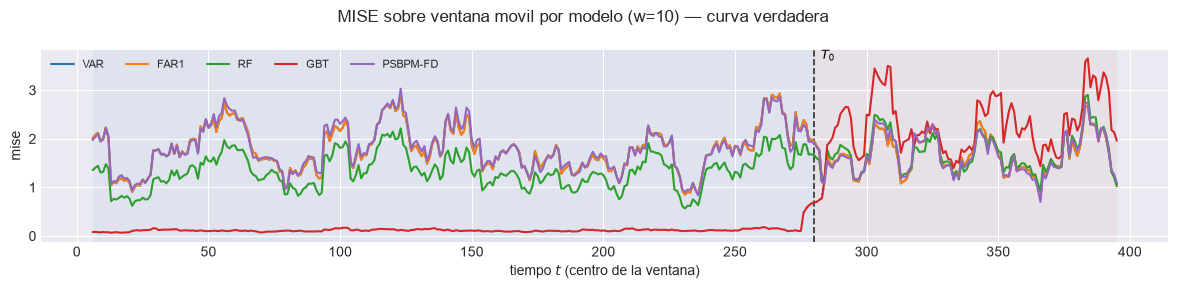

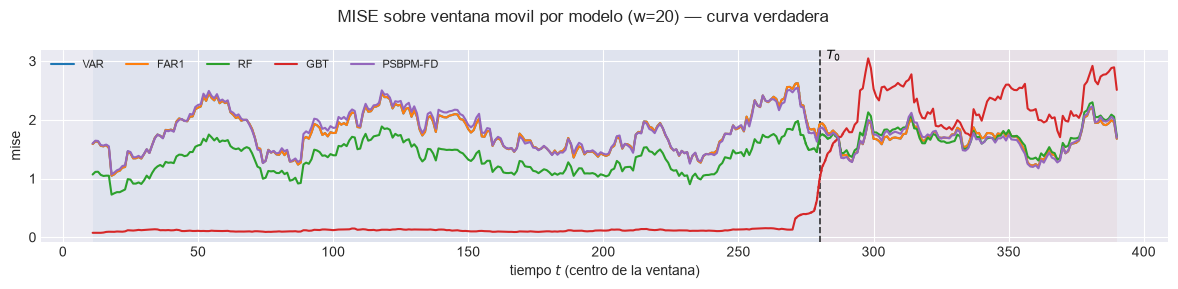

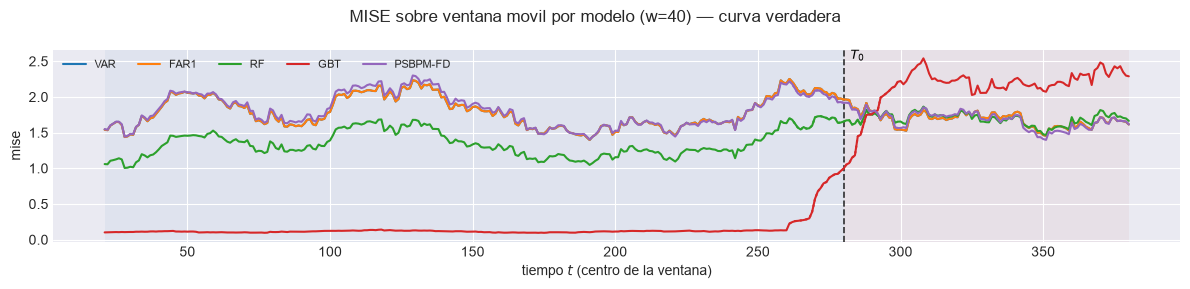

w= 10 dibuja: ['FAR1', 'GBT', 'PSBPM-FD', 'RF', 'VAR']
w= 20 dibuja: ['FAR1', 'GBT', 'PSBPM-FD', 'RF', 'VAR']
w= 40 dibuja: ['FAR1', 'GBT', 'PSBPM-FD', 'RF', 'VAR']

excluidas de TODAS las figuras: ['(truncamiento FPCA)', 'media', 'persistencia'] — siguen en las tablas y en los CSV


In [17]:
# Una figura por ancho, con SOLO los modelos (ver EXCLUIR_DE_FIGURA).
fuera = set(EXCLUIR_DE_FIGURA)

for w in VENTANAS_W:
    tw = tablas_w[w]
    tf = tw[~tw["modelo"].isin(fuera)].copy()
    tf.attrs["w"] = w
    plot_ventana_movil(
        tf, T0, ["mise"], columna_grupo="modelo",
        title=f"MISE sobre ventana movil por modelo (w={w}) — curva verdadera",
        save_path=str(PATHS["out_report"] / f"{PREFIJO + 2}_ventana_modelos_w{w}.png"),
        verbose=False)
    plt.show()

for w in VENTANAS_W:
    dibujadas = sorted(set(tablas_w[w]["modelo"].unique()) - fuera)
    print(f"w={w:>3} dibuja: {dibujadas}")
print("\nexcluidas de TODAS las figuras:",
      sorted(fuera & set(ventana_df["modelo"].unique())),
      "— siguen en las tablas y en los CSV")

In [18]:
# Lectura numerica del salto en T0 por modelo, excluyendo las ventanas que lo
# cruzan. Aqui SI van todas las series: en una tabla las lineas base no
# estorban y son la referencia con la que se lee el resto.
limpio = ventana_df[~ventana_df["cruza_T0"]]
salto = (limpio.groupby(["modelo", "bloque"])["mise"].mean()
         .unstack("bloque")
         .rename(columns={"train": "MISE_train", "test": "MISE_test"}))
salto["salto"] = salto["MISE_test"] / salto["MISE_train"]
salto = salto.sort_values("MISE_test")
salto.to_csv(PATHS["out_report"] / f"{PREFIJO + 3}_salto_T0.csv")

display(salto.style.format({"MISE_train": "{:.6f}", "MISE_test": "{:.6f}",
                            "salto": "{:.2f}x"})
        .background_gradient(subset=["MISE_test"], cmap="RdYlGn_r")
        .set_caption(f"MISE medio por bloque y salto en T0 (w={W_COMP}, "
                     "ventanas que cruzan excluidas)"))

bloque,MISE_test,MISE_train,salto
modelo,,,
(truncamiento FPCA),0.057677,0.066549,0.87x
PSBPM-FD,1.679081,1.801553,0.93x
VAR,1.679446,1.781046,0.94x
FAR1,1.680360,1.781069,0.94x
RF,1.716281,1.321365,1.30x
media,1.834827,1.954419,0.94x
GBT,2.285112,0.114458,19.96x
persistencia,3.353083,3.362737,1.00x


## 6. Contraste con el PSBPM-FD

Las cifras agregadas del modelo propuesto se leen de los CSV de `15_04`. La
que decide el eje 1 es el **MISE en el bloque de prueba**.

In [19]:
f_psbp_s = PATHS["out_report"] / "50_metricas_scores.csv"
f_psbp_f = PATHS["out_report"] / "51_metricas_funcionales.csv"

psbp = {}
if f_psbp_s.exists() and f_psbp_f.exists():
    _s = pd.read_csv(f_psbp_s, index_col=[0, 1])
    _f = pd.read_csv(f_psbp_f, index_col=0)
    for b in ("train", "test"):
        psbp[b] = {"RMSE_scores": float(_s.loc[b, "RMSE"].mean()),
                   "R2_scores":   float(_s.loc[b, "R2"].mean()),
                   "MISE":        float(_f.loc[b, "MISE"]),
                   "RMSE_func":   float(_f.loc[b, "RMSE_f"])}
    print("OK cifras del PSBPM-FD leidas de 50_/51_")
    print(f"   MISE test = {psbp['test']['MISE']:.6f}")
else:
    print("FALTAN 50_metricas_scores.csv y/o 51_metricas_funcionales.csv.")
    print("Ejecuta el notebook _04; §6 queda sin la fila del PSBPM-FD.")

OK cifras del PSBPM-FD leidas de 50_/51_
   MISE test = 1.656905


In [20]:
if psbp:
    filas = []
    for b in ("train", "test"):
        filas.append({"bloque": b, "modelo": "PSBPM-FD", **psbp[b]})
        for nom in PRED:
            r = comp_df.loc[(b, nom)]
            filas.append({"bloque": b, "modelo": nom,
                          "RMSE_scores": float(r["RMSE_scores"]),
                          "R2_scores": float(r["R2_scores"]),
                          "MISE": float(r["MISE"]),
                          "RMSE_func": float(r["RMSE_func"])})
        filas.append({"bloque": b, "modelo": "(truncamiento FPCA)",
                      "RMSE_scores": np.nan, "R2_scores": np.nan,
                      "MISE": MISE_TRUNC[b], "RMSE_func": np.nan})

    final_df = pd.DataFrame(filas).set_index(["bloque", "modelo"])
    # La primera fila de cada bloque es, por construccion, la del PSBPM-FD.
    ref_bloque = final_df.groupby("bloque")["MISE"].transform(lambda s: s.iloc[0])
    final_df["MISE_rel_PSBP"] = final_df["MISE"] / ref_bloque
    final_df.to_csv(PATHS["out_report"] / f"{PREFIJO + 4}_tabla_final.csv")

    display(final_df.style
            .format({"RMSE_scores": "{:.4f}", "R2_scores": "{:.4f}",
                     "MISE": "{:.6f}", "RMSE_func": "{:.6f}",
                     "MISE_rel_PSBP": "{:.3f}x"}, na_rep="—")
            .background_gradient(subset=["MISE"], cmap="RdYlGn_r")
            .set_caption("Tabla del eje 1 · MISE contra la curva VERDADERA · "
                         "MISE_rel_PSBP < 1 significa mejor que el PSBPM-FD"))

In [21]:
if psbp:
    print("Veredicto sobre el bloque de PRUEBA (MISE, menor es mejor)\n")
    ref = psbp["test"]["MISE"]
    orden = (final_df.loc["test", "MISE"]
             .drop(index=["(truncamiento FPCA)"]).sort_values())
    for i, (nom, v) in enumerate(orden.items(), 1):
        marca = "   <- PSBPM-FD" if nom == "PSBPM-FD" else ""
        print(f"  {i}. {nom:22s} MISE={v:.6f}   ({v / ref:.3f}x){marca}")

    mejores = [n for n, v in orden.items() if v < ref]
    print()
    if not mejores:
        print("El PSBPM-FD domina en MISE a todas las referencias en el test.")
    else:
        print(f"Superan al PSBPM-FD en MISE: {', '.join(mejores)}")
    print()
    print("En el Escenario 5 la dinamica es lineal y escalar por componente: el")
    print("VAR es el techo practico y el orden de arriba es el esperado. La")
    print("cifra informativa NO es el promedio sino el RMSE por componente, en")
    print("la tabla 71_: la senal vive en una sola direccion.")

    _piso = MISE_TRUNC["test"] / ref
    print(f"\nEl piso de truncamiento es {_piso:.1%} del MISE del PSBPM-FD en test."
          + ("\n  <- la representacion domina el error; subir M rinde mas que "
             "cambiar de modelo" if _piso > 0.7 else ""))

Veredicto sobre el bloque de PRUEBA (MISE, menor es mejor)

  1. VAR                    MISE=1.644932   (0.993x)
  2. FAR1                   MISE=1.645668   (0.993x)
  3. PSBPM-FD               MISE=1.656905   (1.000x)   <- PSBPM-FD
  4. RF                     MISE=1.684161   (1.016x)
  5. media                  MISE=1.799853   (1.086x)
  6. GBT                    MISE=2.253751   (1.360x)
  7. persistencia           MISE=3.256992   (1.966x)

Superan al PSBPM-FD en MISE: VAR, FAR1

En el Escenario 5 la dinamica es lineal y escalar por componente: el
VAR es el techo practico y el orden de arriba es el esperado. La
cifra informativa NO es el promedio sino el RMSE por componente, en
la tabla 71_: la senal vive en una sola direccion.

El piso de truncamiento es 3.4% del MISE del PSBPM-FD en test.


### 6.1 El veredicto del caso nulo

Lo que decide si esta corrida responde `§03_06` no es el ranking anterior sino
si el truncamiento FPCA descarta la direccion informativa.

In [22]:
f_alin = PATHS["out_report"] / "10_alineacion_fpca_generador.csv"
if f_alin.exists():
    alin = pd.read_csv(f_alin)
    display(alin.style.set_caption(
        "Alineacion FPCA - Fourier del generador (escrita por 15_01 §4)"))
    col_phi = next((c for c in alin.columns if "phi" in c.lower()), None)
    col_ret = next((c for c in alin.columns if "reten" in c.lower()), None)
    if col_phi and col_ret:
        activas = alin[alin[col_phi].abs() > 1e-12]
        retenidas = activas[activas[col_ret].astype(bool)]
        print(f"\ndirecciones con dinamica: {len(activas)}   "
              f"retenidas por el truncamiento: {len(retenidas)}")
        if len(retenidas) == len(activas) and len(activas) > 0:
            print("\nCASO NULO: el truncamiento RETIENE la direccion informativa.")
            print("La corrida es un control valido —el metodo recupera la")
            print("dinamica cuando la representacion la conserva— pero NO")
            print("responde §03_06, que exige M <= 2. Declararlo al reportar.")
        else:
            print("\nEl truncamiento DESCARTA parte de la dinamica: el escenario")
            print("esta operando como fue disenado.")
else:
    print(f"Falta {f_alin.name}; ejecuta 15_01 §4.")
    print("Recordatorio: con M=4 esta corrida esta en CASO NULO.")

,fpc,fourier_alineada,corr_alineacion,var_ratio,ar1_score,phi_generador,es_predecible,retenida
0,1,1,0.998853,0.503829,0.010730,0.000000,False,True
1,2,2,0.997043,0.263687,0.027400,0.000000,False,True
2,3,3,0.992173,0.100975,0.858785,0.900000,True,True
3,4,4,0.970022,0.064074,0.027378,0.000000,False,True
4,5,5,0.983926,0.034627,0.037684,0.000000,False,True
5,6,6,0.956575,0.015876,0.065082,0.000000,False,False
6,7,7,0.956113,0.009009,-0.018200,0.000000,False,False
7,8,8,0.929276,0.003429,-0.050156,0.000000,False,False
8,9,9,0.897190,0.002402,-0.037391,0.000000,False,False
9,10,10,0.831929,0.001433,-0.090479,0.000000,False,False



direcciones con dinamica: 1   retenidas por el truncamiento: 1

CASO NULO: el truncamiento RETIENE la direccion informativa.
La corrida es un control valido —el metodo recupera la
dinamica cuando la representacion la conserva— pero NO
responde §03_06, que exige M <= 2. Declararlo al reportar.


## 7. Resumen ejecutable

In [23]:
resumen = {
    "experiment_id": EXPERIMENT_ID,
    "objetivo_evaluacion": OBJETIVO,
    "modo_residuo": MODO_RESIDUO,
    "n_lags": N_LAGS, "M_fpca": M_fpca,
    "n_train_origenes": int(es_train.sum()),
    "n_test_origenes": int((~es_train).sum()),
    "w_ventana": W_COMP,
    "p_bic_libre": int(_p_bic),
    "far_hs_norm": round(_hs, 6),
    "far_hs_referencia": HS_REFERENCIA,
    "far_radio_espectral": round(_rho, 6),
    "mise_truncamiento_test": round(float(MISE_TRUNC["test"]), 8),
    **{f"mise_test_{n}": round(float(comp_df.loc[("test", n), "MISE"]), 8)
       for n in PRED},
}
if psbp:
    resumen["mise_test_PSBPM-FD"] = round(psbp["test"]["MISE"], 8)

pd.Series(resumen).to_csv(
    PATHS["out_report"] / f"{PREFIJO + 5}_resumen_comparacion.csv", header=False)
for k, v in resumen.items():
    print(f"  {k:26s}: {v}")

print("\nParametros declarados de cada competidor:")
for n, txt in INFO.items():
    print(f"  {n:14s}: {txt}")
print(f"\nTablas y figuras en {PATHS['out_report']}  "
      f"(archivos {PREFIJO}-{PREFIJO + 5})")

  experiment_id             : escenario_5_r01
  objetivo_evaluacion       : curva_verdadera
  modo_residuo              : ninguno
  n_lags                    : 1
  M_fpca                    : 5
  n_train_origenes          : 279
  n_test_origenes           : 120
  w_ventana                 : 20
  p_bic_libre               : 1
  far_hs_norm               : 0.908222
  far_hs_referencia         : phi = 0.9 en una sola dirección de Fourier, 0 en el resto
  far_radio_espectral       : 0.857438
  mise_truncamiento_test    : 0.05713249
  mise_test_VAR             : 1.64493175
  mise_test_FAR1            : 1.6456678
  mise_test_RF              : 1.68416097
  mise_test_GBT             : 2.25375079
  mise_test_media           : 1.79985262
  mise_test_persistencia    : 3.25699213
  mise_test_PSBPM-FD        : 1.65690546

Parametros declarados de cada competidor:
  VAR           : p=1, 30 parametros
  FAR1          : K=5, ||Psi||_HS=0.9082
  RF            : n_estimators=500, leaf>=5
  GBT          